In [10]:
import pandas as pd
df =pd.read_csv("VNQ.csv")
df.head()
df.tail()
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,3774.000000,3774.000000,3774.000000,3774.000000,3774.000000,3.774000e+03
mean,78.514515,79.056293,77.906428,78.507795,57.045586,4.203586e+06
std,14.237643,14.283207,14.183809,14.231508,18.162819,2.221748e+06
min,40.990002,41.529999,40.330002,41.040001,21.506914,6.611000e+05
25%,69.355000,69.742502,68.802502,69.332500,41.214730,2.688300e+06
50%,80.750000,81.325001,80.120003,80.699997,57.528482,3.765600e+06
75%,86.029999,86.734999,85.269997,86.029999,71.575989,5.164000e+06
max,116.209999,116.709999,115.650002,116.010002,97.226730,2.247180e+07


In [11]:
df.isnull()

,Date,Open,High,Low,Close,Adj Close,Volume
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
3769,False,False,False,False,False,False,False
3770,False,False,False,False,False,False,False
3771,False,False,False,False,False,False,False
3772,False,False,False,False,False,False,False


In [12]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
3769,False
3770,False
3771,False
3772,False


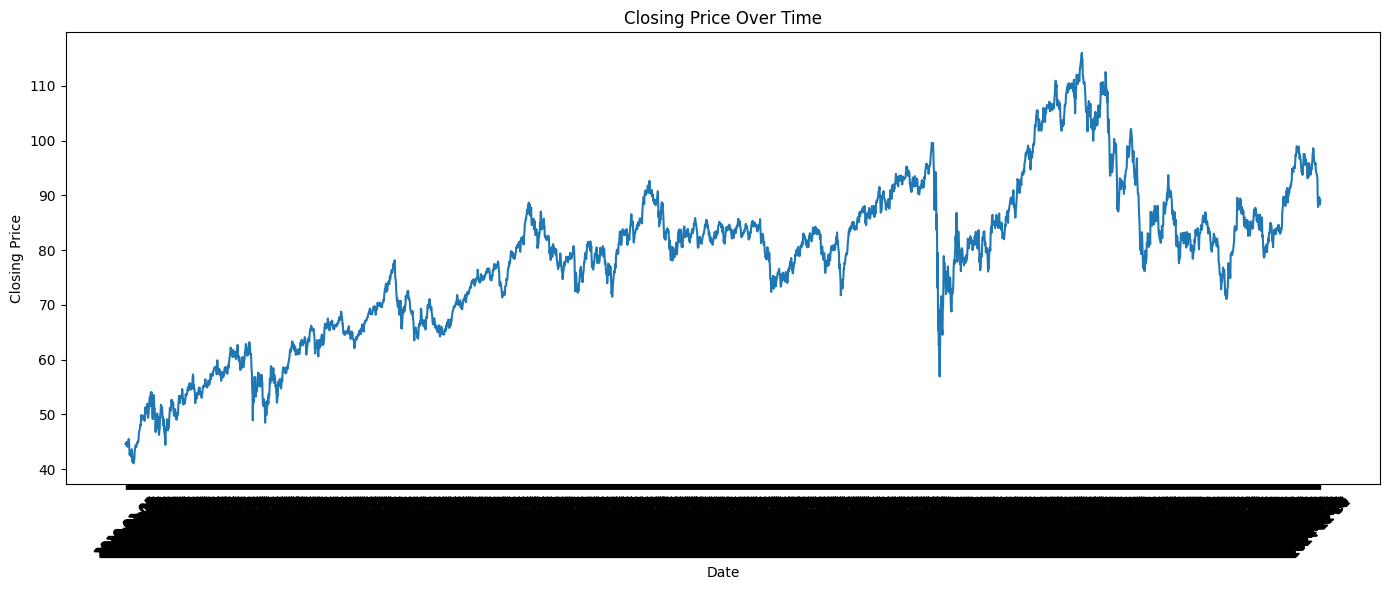

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Close"])
plt.title("Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("plot.png")
plt.show()

In [18]:
df["Daily_Return"] = df["Close"].pct_change()

<function matplotlib.pyplot.show(close=None, block=None)>

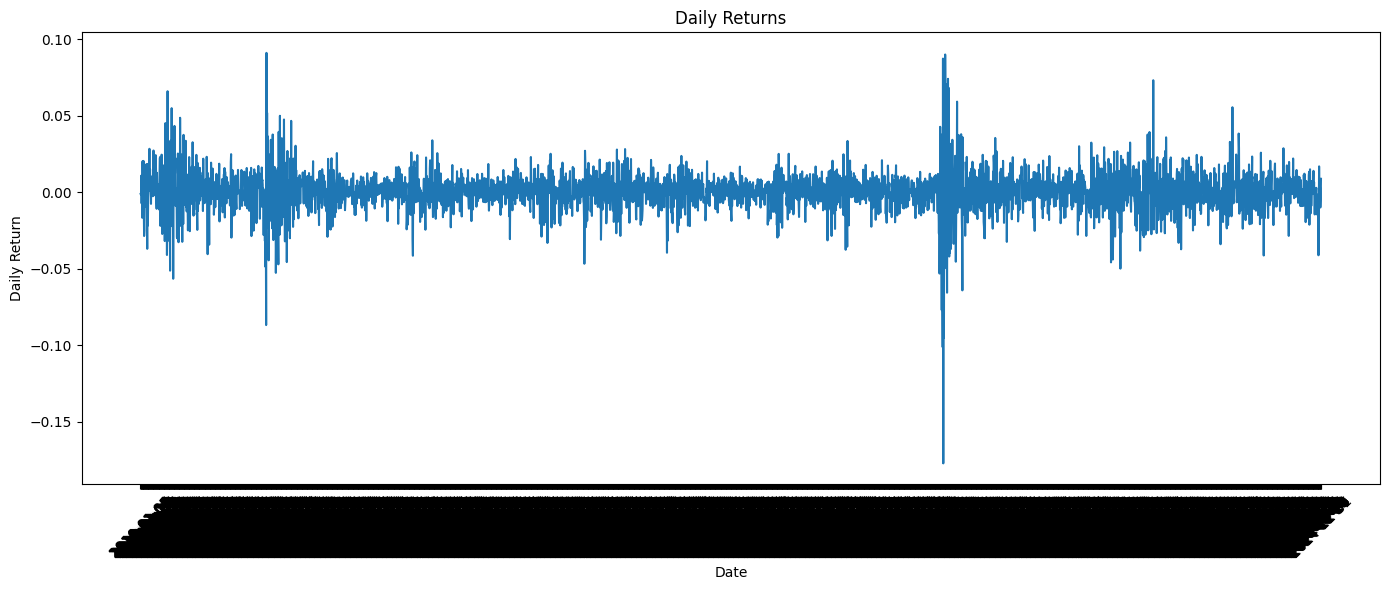

In [19]:
plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Daily_Return"])
plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show

In [21]:
df["volatility"] = df["Daily_Return"].rolling(window=30).std()

In [24]:
df["MA_10"] = df["Close"].rolling(window=10).mean()
df["MA_30"] = df["Close"].rolling(window=30).mean()
df["volatility_10"] = df["Daily_Return"].rolling(window=10).std()
df["Momentum_10"] = df["Close"] - df["Close"].shift(10)
df["Return_5"] = df["Close"].pct_change(5)
df["Return_20"] = df["Close"].pct_change(20)
df.head()


,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return,volatility,MA_10,MA_30,volatility_10,Momentum_10,Return_5,Return_20
0,2010-01-04,45.220001,45.419998,44.200001,44.549999,23.346331,2408400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-05,44.500000,44.580002,43.930000,44.500000,23.320124,2054200,-0.001122,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-06,44.520000,44.840000,44.299999,44.419998,23.278194,2471200,-0.001798,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-07,44.459999,45.099998,43.950001,44.900002,23.529734,2091700,0.010806,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-08,44.810001,44.849998,44.180000,44.570000,23.356806,2682000,-0.007350,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
df = df.dropna().copy()
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0
Daily_Return,0
volatility,0
MA_10,0


In [28]:
df["Target"] = df["Daily_Return"].shift(-1)
df.dropna().copy()

,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return,volatility,MA_10,MA_30,volatility_10,Momentum_10,Return_5,Return_20,Target
30,2010-02-17,43.310001,43.750000,43.240002,43.580002,22.837999,3139000,0.009030,0.015936,41.995000,43.275334,0.019946,-0.049999,0.061891,-0.042198,0.014915
31,2010-02-18,43.410000,44.349998,43.270000,44.230000,23.178625,2737200,0.014915,0.016185,42.126000,43.266334,0.019541,1.310001,0.075632,-0.016893,0.000678
32,2010-02-19,44.029999,44.500000,43.860001,44.259998,23.194340,3250100,0.000678,0.016182,42.418999,43.261000,0.013672,2.929996,0.066249,0.012815,0.002485
33,2010-02-22,44.400002,44.669998,44.150002,44.369999,23.251987,1757800,0.002485,0.016062,42.646999,43.243333,0.013108,2.279999,0.056429,0.041549,-0.007663
34,2010-02-23,44.209999,44.509998,43.930000,44.029999,23.073818,2715900,-0.007663,0.016067,42.932999,43.225333,0.010299,2.860001,0.019449,0.026340,0.010220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3768,2024-12-23,88.180000,88.930000,87.839996,88.820000,83.815506,4548900,-0.005709,0.010801,91.855000,94.489334,0.014736,-7.059998,-0.050257,-0.077099,0.006643
3769,2024-12-24,88.550003,89.510002,88.510002,89.410004,84.372269,2182600,0.006643,0.010916,91.347000,94.289667,0.015135,-5.079994,-0.039325,-0.083726,0.002684
3770,2024-12-26,89.169998,89.739998,88.730003,89.650002,84.598747,2577400,0.002684,0.010719,90.885001,94.142000,0.015330,-4.619995,0.004707,-0.084924,-0.010039
3771,2024-12-27,89.120003,89.769997,88.500000,88.750000,83.749458,3816700,-0.010039,0.010741,90.348000,93.947000,0.015359,-5.370003,0.010245,-0.099899,-0.004958


In [36]:
import numpy as np
df= df.dropna().copy()
df["Target"] = df["Daily_Return"].shift(-1)
df = df.dropna().copy()
x = df.select_dtypes(include=np.number).drop(columns=["Target"])
y = df["Target"]
print("x shape:", x.shape)
print("y shape:", y.shape)


x shape: (3742, 14)
y shape: (3742,)


In [37]:
split = int(len(df) * 0.8)
x_train = x.iloc[:split]
x_test = x.iloc[split:]
y_train = y.iloc[:split]
y_test = y.iloc[split:]
print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (2993, 14)
Testing data: (749, 14)


In [41]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)
print("model training completed successfully.")

model training completed successfully.


In [44]:
predictions = model.predict(x_test)
print("predicted Next-Day Returns:")
print(predictions[:10])

predicted Next-Day Returns:
[-2.76042336e-03 -4.76571386e-03 -1.16235934e-03 -5.57136385e-03
 -5.99911977e-03  5.97708099e-04 -6.75323972e-05 -4.22272670e-03
 -1.58109187e-03  5.58787285e-04]
